# CaVFish – Stage 3 Morphometric Measurements
### Phenotypic Analysis from Keypoint Predictions
This notebook demonstrates **Stage 3** of the CaVFish pipeline:  
computing morphometric measurements from predicted anatomical keypoints.

---

## 📌 Overview

After obtaining keypoint predictions from Stage 2 (inference), we compute phenotypic traits by measuring Euclidean distances between anatomically meaningful keypoint pairs.

**Input:** JSON file with predicted keypoint coordinates  
**Output:** CSV/Excel file with morphometric measurements (absolute and SL-normalized)

In [1]:
from pathlib import Path
import os, sys

def find_root(start: Path, marker: str = "custom_transforms.py") -> Path:
    p = start.resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError(f"Could not find {marker} above {start}")

PROJECT_ROOT = find_root(Path.cwd(), "custom_transforms.py")

# Make it available to *this* notebook kernel
sys.path.insert(0, str(PROJECT_ROOT))

# Make it available to subprocesses launched from this notebook (e.g., !python ...)
os.environ["PYTHONPATH"] = f"{PROJECT_ROOT}:{os.environ.get('PYTHONPATH','')}"

print("PROJECT_ROOT =", PROJECT_ROOT)
print("PYTHONPATH   =", os.environ["PYTHONPATH"])

PROJECT_ROOT = /Users/josuedelarosa/Documents/BIVL2ab/projects/scientific-cavfish/cavfish-original/CaVFish
PYTHONPATH   = /Users/josuedelarosa/Documents/BIVL2ab/projects/scientific-cavfish/cavfish-original/CaVFish:


---

## 🔗 Pre-trained Weights

This notebook expects keypoint predictions from Stage 2 (Inference). You have two options:

### Option 1: Use Pre-trained Models (Recommended - No Training Needed)
Download pre-trained weights from [GitHub Releases](https://github.com/josuedelarosa/CaVFish-MORPH/releases):

```bash
cd ../checkpoints

# Download all 4 pre-trained models
wget https://github.com/josuedelarosa/CaVFish-MORPH/releases/download/baseline/baseline.pth
wget https://github.com/josuedelarosa/CaVFish-MORPH/releases/download/baseline-log/baseline-log.pth
wget https://github.com/josuedelarosa/CaVFish-MORPH/releases/download/phenoloss/phenoloss.pth
wget https://github.com/josuedelarosa/CaVFish-MORPH/releases/download/phenoloss-log/phenoloss-log.pth

cd ../STAGES
```

Then run Stage 2 inference using `../STAGES/2-inference.ipynb`

### Option 2: Train Your Own Models
Follow Stage 1 training first (`../STAGES/1-training.ipynb`), then run inference in Stage 2

## 📊 Morphometric Measurements

The following 13 standard measurements are computed from the 20 anatomical keypoints:

| # | Measurement | Keypoints | Description |
|---|-------------|-----------|-------------|
| 1 | **BI** | 0 → 1 | Body Index: Upper Snout Tip → Caudal Peduncle Center |
| 2 | **Bd** | 2 → 3 | Body Depth: Dorsal Body → Pelvic Fin Base |
| 3 | **Hd** | 4 → 5 | Head Depth: Upper Head → Barbel Base |
| 4 | **CPd** | 6 → 7 | Caudal Peduncle Depth: Mid-Dorsal Trunk → Ventral Trunk |
| 5 | **CFd** | 8 → 9 | Caudal Fin Depth: Upper Caudal Base → Lower Caudal Fin Tip |
| 6 | **Ed** | 10 → 11 | Eye Diameter: Eye Center → Posterior Eye Margin |
| 7 | **Eh** | 12 → 3 | Eye Height: Lower Eye Margin → Pelvic Fin Base |
| 8 | **JI** | 0 → 13 | Jaw Index: Upper Snout Tip → Lower Jaw Tip |
| 9 | **PFI** | 14 → 15 | Pelvic Fin Index: Operculum Lower Edge → Pelvic Fin Tip |
| 10 | **PFi** | 14 → 3 | Pelvic Fin insertion: Operculum Lower Edge → Pelvic Fin Base |
| 11 | **HL** | 0 → 16 | Head Length: Upper Snout Tip → Operculum Upper Edge |
| 12 | **DL** | 2 → 17 | Dorsal Length: Dorsal Body → Dorsal Fin Tip |
| 13 | **AL** | 18 → 19 | Anal Length: Anal Fin Base → Anal Fin Tip |

**Note:** All measurements are provided in both absolute (pixels) and BI-normalized (unitless) formats for morphometric analysis.

## 🔬 Compute Measurements from Keypoint Predictions

Using the `compute_phenotypic_measurements.py` script to process predicted keypoints:

In [2]:
## Compute morphometric measurements from predicted keypoints

!python ../demo/compute_phenotypic_measurements.py \
    ../demo/files/result_keypoints.json \
    --output ../demo/files/measurements.csv \
    --format csv

Loading keypoints from ../demo/files/result_keypoints.json...
Found 1 image (single-image format)

Saving 1 measurements to ../demo/files/measurements.csv...

SUMMARY STATISTICS (in pixels)
                BI          Bd         Hd  ...          HL         DL          AL
count     1.000000    1.000000    1.00000  ...    1.000000    1.00000    1.000000
mean   1398.127894  547.792411  234.87508  ...  325.914876  353.99862  188.520456
std            NaN         NaN        NaN  ...         NaN        NaN         NaN
min    1398.127894  547.792411  234.87508  ...  325.914876  353.99862  188.520456
25%    1398.127894  547.792411  234.87508  ...  325.914876  353.99862  188.520456
50%    1398.127894  547.792411  234.87508  ...  325.914876  353.99862  188.520456
75%    1398.127894  547.792411  234.87508  ...  325.914876  353.99862  188.520456
max    1398.127894  547.792411  234.87508  ...  325.914876  353.99862  188.520456

[8 rows x 13 columns]

SL-NORMALIZED MEASUREMENTS (unitless)
        Bd

## 📈 Analyze Results

Load and inspect the computed measurements:

In [3]:
import pandas as pd
import numpy as np

# Load measurements
df = pd.read_csv('../demo/files/measurements.csv')

print(f"Total specimens analyzed: {len(df)}")
print(f"\nMeasurement columns: {len([c for c in df.columns if c not in ['image', 'mean_confidence', 'min_confidence']])}")
print(f"\nDataFrame shape: {df.shape}")
print("\n" + "="*80)
print("FIRST FEW ROWS")
print("="*80)
print(df.head())

Total specimens analyzed: 1

Measurement columns: 25

DataFrame shape: (1, 28)

FIRST FEW ROWS
          image           BI          Bd         Hd         CPd         CFd  \
0  cavfish1.jpg  1398.127894  547.792411  234.87508  140.113992  442.515934   

           Ed         Eh          JI         PFI  ...   Ed_norm   Eh_norm  \
0  109.041387  560.41444  110.592423  291.901179  ...  0.077991  0.400832   

   JI_norm  PFI_norm  PFi_norm   HL_norm   DL_norm   AL_norm  mean_confidence  \
0   0.0791   0.20878  0.234487  0.233108  0.253195  0.134838         0.967527   

   min_confidence  
0        0.867323  

[1 rows x 28 columns]


### Summary Statistics

Descriptive statistics for absolute measurements (in pixels):

In [4]:
# Select absolute measurement columns (exclude normalized and metadata)
measure_cols = [col for col in df.columns 
                if col not in ['image', 'mean_confidence', 'min_confidence']
                and not col.endswith('_norm')]

print("="*80)
print("ABSOLUTE MEASUREMENTS (pixels)")
print("="*80)
df[measure_cols].describe().round(2)

ABSOLUTE MEASUREMENTS (pixels)


,BI,Bd,Hd,CPd,CFd,Ed,Eh,JI,PFI,PFi,HL,DL,AL
count,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.0,1.00
mean,1398.13,547.79,234.88,140.11,442.52,109.04,560.41,110.59,291.9,327.84,325.91,354.0,188.52
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1398.13,547.79,234.88,140.11,442.52,109.04,560.41,110.59,291.9,327.84,325.91,354.0,188.52
25%,1398.13,547.79,234.88,140.11,442.52,109.04,560.41,110.59,291.9,327.84,325.91,354.0,188.52
50%,1398.13,547.79,234.88,140.11,442.52,109.04,560.41,110.59,291.9,327.84,325.91,354.0,188.52
75%,1398.13,547.79,234.88,140.11,442.52,109.04,560.41,110.59,291.9,327.84,325.91,354.0,188.52
max,1398.13,547.79,234.88,140.11,442.52,109.04,560.41,110.59,291.9,327.84,325.91,354.0,188.52


### BI-Normalized Measurements

Size-independent measurements (normalized by Body Index):

In [5]:
# Select normalized measurement columns
norm_cols = [col for col in df.columns if col.endswith('_norm')]

if norm_cols:
    print("="*80)
    print("BI-NORMALIZED MEASUREMENTS (unitless)")
    print("="*80)
    print(df[norm_cols].describe().round(4))
else:
    print("No normalized measurements found.")

BI-NORMALIZED MEASUREMENTS (unitless)
       Bd_norm  Hd_norm  CPd_norm  CFd_norm  Ed_norm  Eh_norm  JI_norm  \
count   1.0000    1.000    1.0000    1.0000    1.000   1.0000   1.0000   
mean    0.3918    0.168    0.1002    0.3165    0.078   0.4008   0.0791   
std        NaN      NaN       NaN       NaN      NaN      NaN      NaN   
min     0.3918    0.168    0.1002    0.3165    0.078   0.4008   0.0791   
25%     0.3918    0.168    0.1002    0.3165    0.078   0.4008   0.0791   
50%     0.3918    0.168    0.1002    0.3165    0.078   0.4008   0.0791   
75%     0.3918    0.168    0.1002    0.3165    0.078   0.4008   0.0791   
max     0.3918    0.168    0.1002    0.3165    0.078   0.4008   0.0791   

       PFI_norm  PFi_norm  HL_norm  DL_norm  AL_norm  
count    1.0000    1.0000   1.0000   1.0000   1.0000  
mean     0.2088    0.2345   0.2331   0.2532   0.1348  
std         NaN       NaN      NaN      NaN      NaN  
min      0.2088    0.2345   0.2331   0.2532   0.1348  
25%      0.2088    0

### Keypoint Detection Quality

Confidence scores from the pose estimation model:

In [6]:
print("="*80)
print("KEYPOINT CONFIDENCE SCORES")
print("="*80)
print(f"Mean confidence: {df['mean_confidence'].mean():.4f}")
print(f"Min confidence:  {df['min_confidence'].mean():.4f}")
print(f"\nConfidence distribution:")
df[['mean_confidence', 'min_confidence']].describe().round(4)

KEYPOINT CONFIDENCE SCORES
Mean confidence: 0.9675
Min confidence:  0.8673

Confidence distribution:


,mean_confidence,min_confidence
count,1.0000,1.0000
mean,0.9675,0.8673
std,NaN,NaN
min,0.9675,0.8673
25%,0.9675,0.8673
50%,0.9675,0.8673
75%,0.9675,0.8673
max,0.9675,0.8673


## 📊 Visualize Measurement Distributions

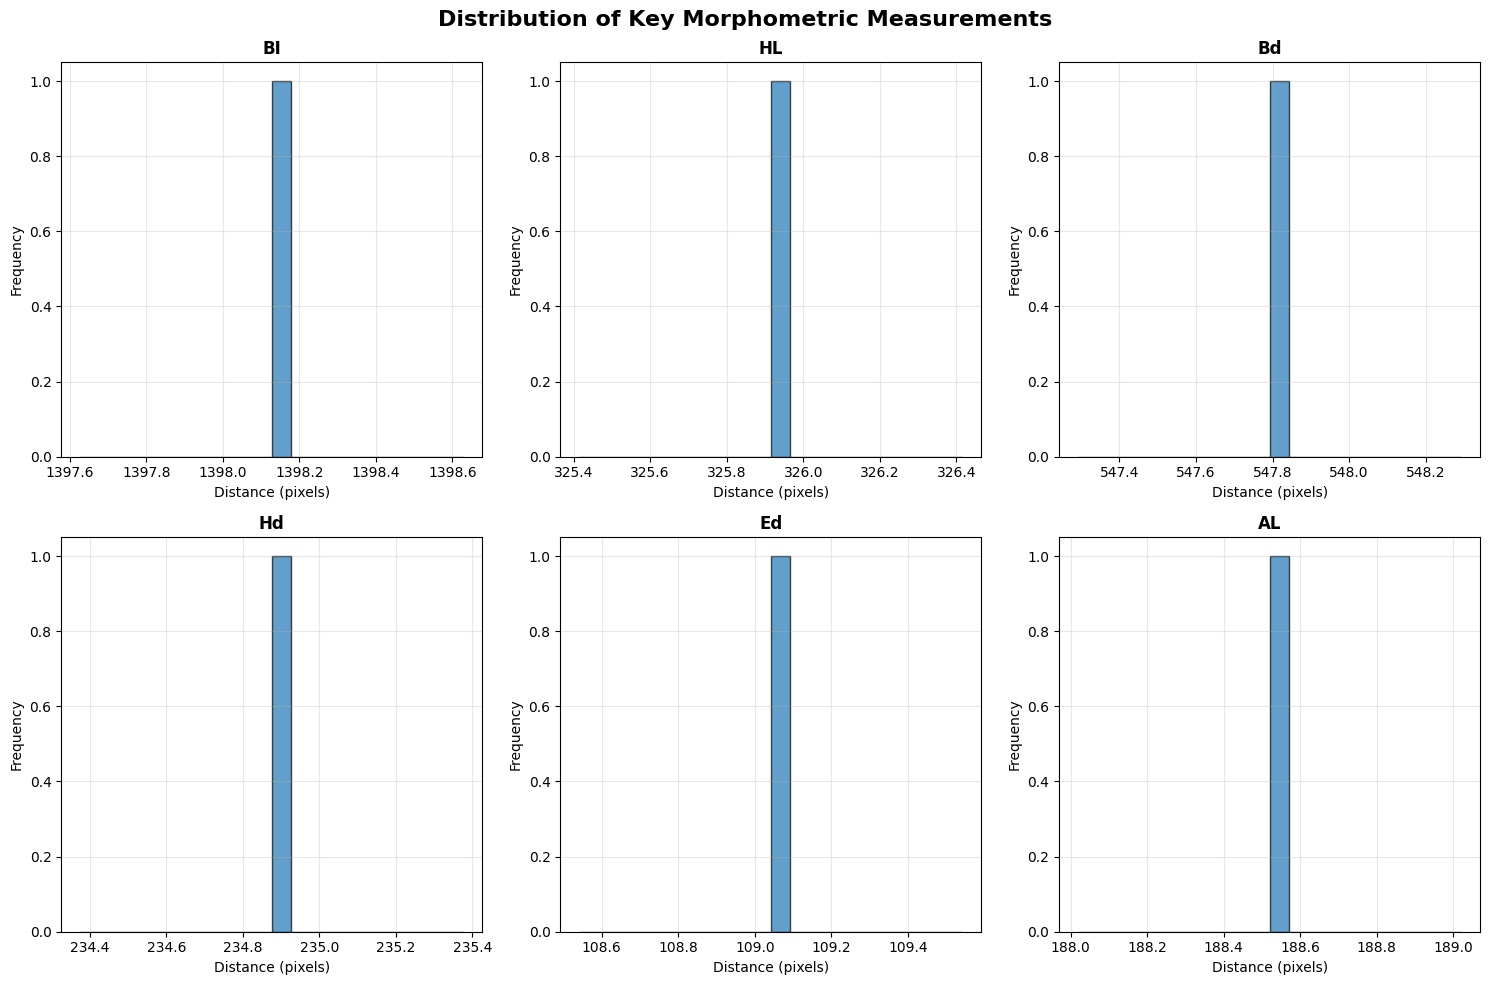

In [7]:
import matplotlib.pyplot as plt

# Plot key measurements
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Key Morphometric Measurements', fontsize=16, fontweight='bold')

key_measures = ['BI', 'HL', 'Bd', 'Hd', 'Ed', 'AL']

for idx, measure in enumerate(key_measures):
    ax = axes[idx // 3, idx % 3]
    if measure in df.columns:
        df[measure].hist(bins=20, ax=ax, edgecolor='black', alpha=0.7)
        ax.set_title(f'{measure}', fontweight='bold')
        ax.set_xlabel('Distance (pixels)')
        ax.set_ylabel('Frequency')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 💾 Export Results

The measurements have been saved to:
- **CSV:** `demo/files/measurements.csv`

You can also export to other formats:

In [8]:
## Export to Excel (optional)
# df.to_excel('../demo/files/measurements.xlsx', index=False)
# print("Exported to measurements.xlsx")

## Export to JSON (optional)
# df.to_json('../demo/files/measurements.json', orient='records', indent=2)
# print("Exported to measurements.json")

print("✅ Morphometric analysis complete!")
print(f"   Total specimens: {len(df)}")
print(f"   Measurements per specimen: {len(measure_cols)}")
print(f"   Mean keypoint confidence: {df['mean_confidence'].mean():.3f}")

✅ Morphometric analysis complete!
   Total specimens: 1
   Measurements per specimen: 13
   Mean keypoint confidence: 0.968
